# Transfer Learning with EfficientNet

**Tracked with:** MLflow + DagsHub  
**Model:** EfficientNetB0 (ImageNet weights)  
**Experiments:**
1. Feature Extraction — frozen base, train head only
2. Fine-tuning — unfreeze last N layers
3. Gradual Unfreezing — phase-by-phase unfreeze
4. Layer-wise LR Decay — decayed LR per layer block

---

## 1.  Setup

In [ ]:
!pip install -q mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829

## 2. Imports & Configuration

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import mlflow
import mlflow.keras
import dagshub


In [ ]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS_FEATURE = 30
AUTOTUNE = tf.data.AUTOTUNE

tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. DagsHub & MLflow Configuration



In [ ]:
# connects MLflow to DagsHub


DAGSHUB_USERNAME = "MoojProject"
DAGSHUB_REPO = "efficientnet-food"
DAGSHUB_TOKEN = "13bf92b9dcd3fdaed9511417548d2c7193c649dc"

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN

mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow")
mlflow.set_experiment("food11-transfer-learning")

print("MLflow tracking URI:", mlflow.get_tracking_uri())

MLflow tracking URI: https://dagshub.com/MoojProject/efficientnet-food.mlflow


## 4. Data Loading

In [ ]:
def get_data_extract():
    if 'dataset' in os.listdir():
        print('Dataset already exists — skipping download.')
    else:
        print('Downloading dataset...')
        !wget -q -O food-data.zip https://www.kaggle.com/api/v1/datasets/download/trolukovich/food11-image-dataset
        print('Extracting...')
        !mkdir dataset
        !unzip -q food-data.zip -d dataset
        print('Done!')

get_data_extract()

Dataset already exists — skipping download.


## 5. Dataset Preprocessing

In [ ]:
image_paths = glob.glob("dataset/*/*/*.jpg")
labels = [p.split("/")[-2] for p in image_paths]

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total images:", len(df))
print(df.head())
print(df["label"].value_counts())

Total images: 16643
                     image_path label
0  dataset/training/Egg/707.jpg   Egg
1  dataset/training/Egg/411.jpg   Egg
2   dataset/training/Egg/77.jpg   Egg
3   dataset/training/Egg/12.jpg   Egg
4  dataset/training/Egg/641.jpg   Egg
label
Soup               2500
Dessert            2500
Meat               2206
Bread              1724
Egg                1648
Seafood            1505
Fried food         1461
Vegetable-Fruit    1172
Noodles-Pasta       734
Dairy product       721
Rice                472
Name: count, dtype: int64


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 13314
Validation: 1664
Test: 1665


In [ ]:
class_names = sorted(df["label"].unique())
class_to_index = {name: idx for idx, name in enumerate(class_names)}
index_to_class = {idx: name for name, idx in class_to_index.items()}

NUM_CLASSES = len(class_names)

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)   #  [0,255]
    label = class_to_index[label.numpy().decode("utf-8")]
    return image, label

In [ ]:
def process_path(path, label):
    image, label = tf.py_function(
        func=load_image,
        inp=[path, label],
        Tout=[tf.float32, tf.int32]
    )
    image.set_shape((224, 224, 3))
    label.set_shape(())
    return image, label

In [ ]:
data_aug = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
], name="data_augmentation")

In [ ]:
def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["image_path"].values,
        dataframe["label"].values
    ))

    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED)

    ds = ds.map(process_path, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(lambda x, y: (data_aug(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

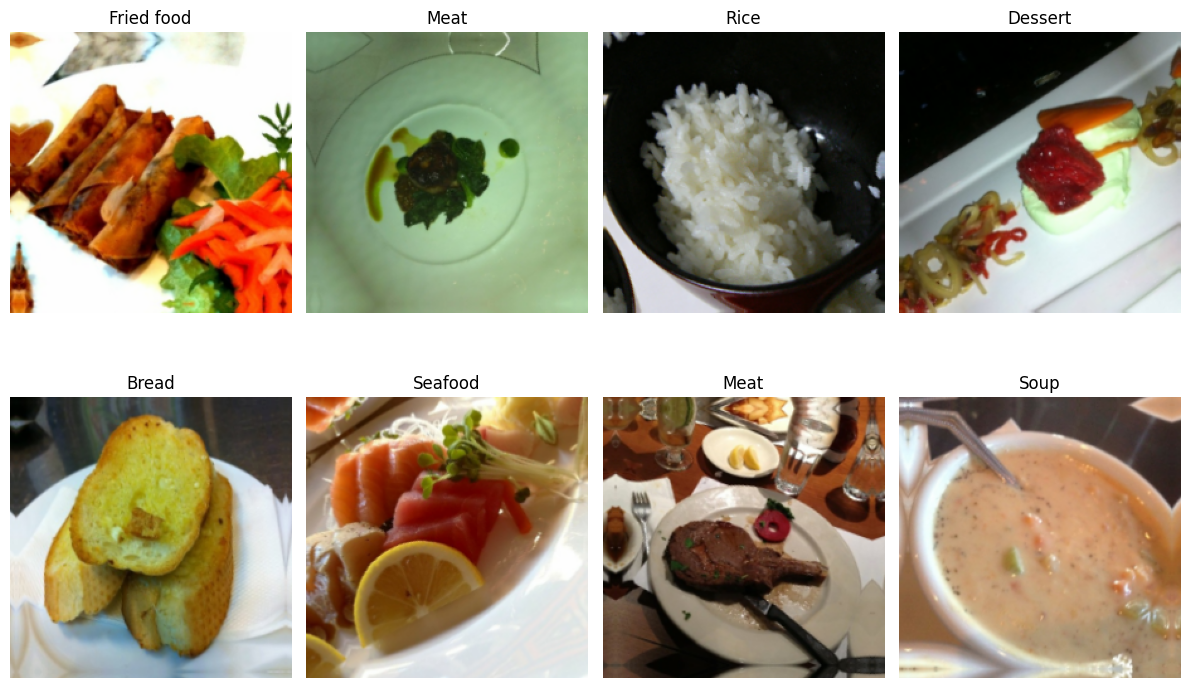

In [ ]:
for images, labels_batch in train_ds.take(1):
    plt.figure(figsize=(12, 8))
    for i in range(8):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(index_to_class[int(labels_batch[i].numpy())])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
print("Sample from the dataset:",next(iter(train_ds))[1])

Sample from the dataset: tf.Tensor([ 8  2  5  4  3  0  3  6  4  9  4  1 10  9  6 10], shape=(16,), dtype=int32)


---
## 6. Experiment 1 — Feature Extraction



In [ ]:
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)
# هذي الملفات بس عشان احفظ كل المودل والنتايج

In [ ]:
def build_feature_extraction_model():
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

In [ ]:
feature_model, feature_base = build_feature_extraction_model()
feature_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │        14,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,063,662 (15.50 MB)

 Trainable params: 14,091 (55.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
feature_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Callbacks

In [ ]:
callbacks = [
    keras.callbacks.TensorBoard(log_dir='./logs'),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="models/feature_extraction_best.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [ ]:
#  Train + MLflow tracking

with mlflow.start_run(
    run_name="EfficientNetB0_FeatureExtraction"):
    mlflow.log_param("experiment_type", "feature_extraction")
    mlflow.log_param("model_name", "EfficientNetB0")
    mlflow.log_param("image_size", IMG_SIZE[0])
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("epochs", EPOCHS_FEATURE)
    mlflow.log_param("learning_rate", 1e-3)
    mlflow.log_param("trainable_base_model", False)
    mlflow.log_param("num_classes", NUM_CLASSES)

    history_feature = feature_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FEATURE,
        callbacks= callbacks
    )

    best_val_acc = max(history_feature.history["val_accuracy"])
    best_val_loss = min(history_feature.history["val_loss"])
    final_train_acc = history_feature.history["accuracy"][-1]
    final_val_acc = history_feature.history["val_accuracy"][-1]

    mlflow.log_metric("best_val_accuracy", best_val_acc)
    mlflow.log_metric("best_val_loss", best_val_loss)
    mlflow.log_metric("final_train_accuracy", final_train_acc)
    mlflow.log_metric("final_val_accuracy", final_val_acc)


Epoch 1/30
833/833 ━━━━━━━━━━━━━━━━━━━━ 230s 250ms/step - accuracy: 0.7639 - loss: 0.7566 - val_accuracy: 0.8678 - val_loss: 0.4074 - learning_rate: 0.0010
Epoch 2/30
833/833 ━━━━━━━━━━━━━━━━━━━━ 185s 222ms/step - accuracy: 0.8399 - loss: 0.4897 - val_accuracy: 0.8894 - val_loss: 0.3382 - learning_rate: 0.0010
Epoch 3/30
833/833 ━━━━━━━━━━━━━━━━━━━━ 185s 222ms/step - accuracy: 0.8584 - loss: 0.4395 - val_accuracy: 0.8972 - val_loss: 0.3165 - learning_rate: 0.0010
Epoch 4/30
833/833 ━━━━━━━━━━━━━━━━━━━━ 185s 222ms/step - accuracy: 0.8644 - loss: 0.4123 - val_accuracy: 0.8960 - val_loss: 0.3088 - learning_rate: 0.0010
Epoch 5/30
833/833 ━━━━━━━━━━━━━━━━━━━━ 203s 223ms/step - accuracy: 0.8681 - loss: 0.3957 - val_accuracy: 0.9044 - val_loss: 0.2973 - learning_rate: 0.0010
Epoch 6/30
833/833 ━━━━━━━━━━━━━━━━━━━━ 185s 222ms/step - accuracy: 0.8704 - loss: 0.3840 - val_accuracy: 0.9008 - val_loss: 0.2965 - learning_rate: 0.0010
Epoch 7/30
833/833 ━━━━━━━━━━━━━━━━━━━━ 187s 224ms/step - accura

In [ ]:
def plot_history(history, prefix):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title(f"{prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"results/{prefix.lower()}_accuracy.png")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title(f"{prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"results/{prefix.lower()}_loss.png")
    plt.show()

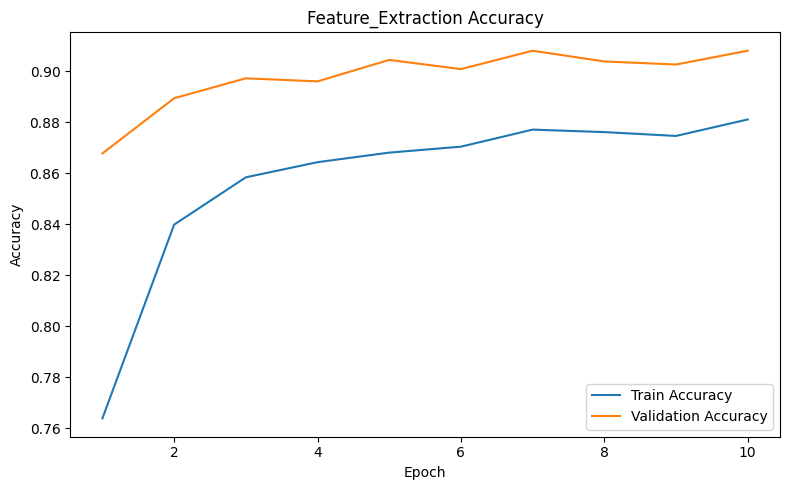

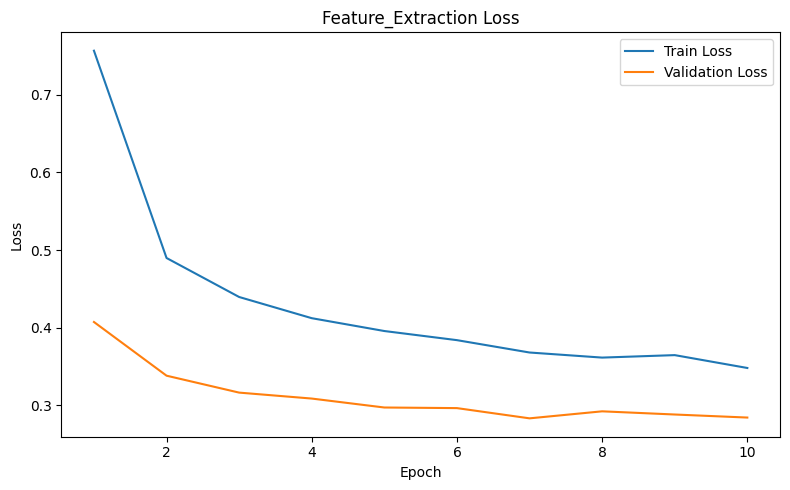

In [ ]:
plot_history(history_feature, "Feature_Extraction")

هذي الطريقه عشان نرفع التشارت في mlflow

In [ ]:
test_loss, test_acc = feature_model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 277ms/step - accuracy: 0.8877 - loss: 0.3254
Test Loss: 0.32538703083992004
Test Accuracy: 0.8876876831054688


In [ ]:
y_true = []
y_pred = []

for images, labels_batch in test_ds:
    preds = feature_model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels_batch.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

                 precision    recall  f1-score   support

          Bread       0.78      0.91      0.84       173
  Dairy product       0.84      0.86      0.85        72
        Dessert       0.88      0.84      0.86       250
            Egg       0.88      0.80      0.84       165
     Fried food       0.81      0.92      0.86       146
           Meat       0.92      0.88      0.90       221
  Noodles-Pasta       0.96      0.99      0.97        73
           Rice       0.93      0.89      0.91        47
        Seafood       0.93      0.85      0.89       151
           Soup       0.96      0.94      0.95       250
Vegetable-Fruit       0.92      0.93      0.92       117

       accuracy                           0.89      1665
      macro avg       0.89      0.89      0.89      1665
   weighted avg       0.89      0.89      0.89      1665



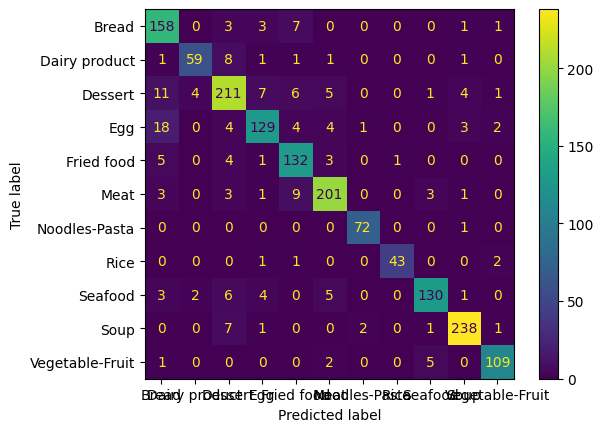

In [ ]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=class_names)

# Log per-epoch metrics في MLflow
for epoch, (ta, va) in enumerate(zip(
    history_feature.history['accuracy'],
    history_feature.history['val_accuracy']
)):
    mlflow.log_metrics({'train_acc': ta, 'val_acc': va}, step=epoch)

In [ ]:
from sklearn.metrics import classification_report

# طريقه مره حلوه عشان نفحظ التقرير وحطيته بمجلد الريسولت اخر شي بحط كل المصادر الي ساعدتني لان شوي معقد الكود
report = classification_report(y_true, y_pred, target_names=class_names)

with open("results/feature_extraction_classification_report.txt", "w") as f:
    f.write(report)

print(report)

                 precision    recall  f1-score   support

          Bread       0.79      0.91      0.85       173
  Dairy product       0.91      0.82      0.86        72
        Dessert       0.86      0.84      0.85       250
            Egg       0.87      0.78      0.82       165
     Fried food       0.82      0.90      0.86       146
           Meat       0.91      0.91      0.91       221
  Noodles-Pasta       0.96      0.99      0.97        73
           Rice       0.98      0.91      0.95        47
        Seafood       0.93      0.86      0.89       151
           Soup       0.95      0.95      0.95       250
Vegetable-Fruit       0.94      0.93      0.94       117

       accuracy                           0.89      1665
      macro avg       0.90      0.89      0.90      1665
   weighted avg       0.89      0.89      0.89      1665



In [ ]:
# Check if an MLflow run is already active
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name="EfficientNetB0_FeatureExtraction_Artifacts"):
    mlflow.log_artifact("results/feature_extraction_accuracy.png")
    mlflow.log_artifact("results/feature_extraction_loss.png")
    mlflow.log_artifact("results/feature_extraction_classification_report.txt")
    mlflow.log_artifact("models/feature_extraction_best.keras")

🏃 View run EfficientNetB0_FeatureExtraction_Artifacts at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/1/runs/8db369a31cd2479dbcbba95560aa09bd
🧪 View experiment at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/1


## Final Result of Experiment 1

- Test Accuracy: **89%**
- Test Loss: **0.325**

This result indicates that EfficientNetB0 worked well as a fixed feature extractor and produced a strong baseline performance on the Food11 dataset.

---
## 7. Experiment 2 — Fine-Tuning


In [ ]:
fine_model = keras.models.load_model("models/feature_extraction_best.keras")
fine_model.summary(show_trainable=True)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_7 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetb0 (Functional) │ (None, 7, 7, 1280)    │  4,049,571 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 11)            │     14,091 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 4,091,846 (15.61 MB)

 Trainable params: 14,091 (55.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 28,184 (110.10 KB)

In [83]:
base_model = None

for layer in fine_model.layers:
    if isinstance(layer, keras.Model):
        base_model = layer
        break

print("Base model name:", base_model.name)
print("Number of layers in base model:", len(base_model.layers))

Base model name: efficientnetb0
Number of layers in base model: 238


## Unfreeze the last layers only

In [84]:
base_model.trainable = True

for layer in base_model.layers:
    layer.trainable = False

unfreeze_last_n = 20

for layer in base_model.layers[-unfreeze_last_n:]:
    if not isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = True

## Check trainable layers

In [85]:
trainable_layers = sum([layer.trainable for layer in base_model.layers])
non_trainable_layers = len(base_model.layers) - trainable_layers

print("Trainable layers in base model:", trainable_layers)
print("Non-trainable layers in base model:", non_trainable_layers)

Trainable layers in base model: 15
Non-trainable layers in base model: 223


In [86]:
EPOCHS_FINE = 10
FINE_TUNE_LR = 1e-5

fine_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [87]:
fine_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="models/fine_tuned_best.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [88]:
with mlflow.start_run(run_name="EfficientNetB0_FineTuning"):
    mlflow.log_param("experiment_type", "fine_tuning")
    mlflow.log_param("model_name", "EfficientNetB0")
    mlflow.log_param("img_size", 224)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("epochs", EPOCHS_FINE)
    mlflow.log_param("learning_rate", FINE_TUNE_LR)
    mlflow.log_param("unfreeze_last_n", unfreeze_last_n)
    mlflow.log_param("num_classes", NUM_CLASSES)

    history_fine = fine_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FINE,
        callbacks=fine_callbacks
    )

    test_loss_fine, test_acc_fine = fine_model.evaluate(test_ds, verbose=1)
    mlflow.log_metric("test_loss", float(test_loss_fine))
    mlflow.log_metric("test_accuracy", float(test_acc_fine))

Epoch 1/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 233s 248ms/step - accuracy: 0.8841 - loss: 0.3444 - val_accuracy: 0.9117 - val_loss: 0.2742 - learning_rate: 1.0000e-05
Epoch 2/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 186s 223ms/step - accuracy: 0.8920 - loss: 0.3259 - val_accuracy: 0.9147 - val_loss: 0.2674 - learning_rate: 1.0000e-05
Epoch 3/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 201s 223ms/step - accuracy: 0.8970 - loss: 0.3107 - val_accuracy: 0.9201 - val_loss: 0.2623 - learning_rate: 1.0000e-05
Epoch 4/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 186s 223ms/step - accuracy: 0.9011 - loss: 0.2924 - val_accuracy: 0.9171 - val_loss: 0.2579 - learning_rate: 1.0000e-05
Epoch 5/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 184s 220ms/step - accuracy: 0.9090 - loss: 0.2772 - val_accuracy: 0.9201 - val_loss: 0.2536 - learning_rate: 1.0000e-05
Epoch 6/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 185s 222ms/step - accuracy: 0.9093 - loss: 0.2640 - val_accuracy: 0.9213 - val_loss: 0.2477 - learning_rate: 1.0000e-05
Epoch 7/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 

KeyboardInterrupt: 

In [ ]:
print("Fine-Tuning Test Loss:", test_loss_fine)
print("Fine-Tuning Test Accuracy:", test_acc_fine)

In [ ]:
plot_history(history_fine, "fine_tuning")

In [ ]:
y_true_fine = []
y_pred_fine = []

for images, labels_batch in test_ds:
    preds = fine_model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true_fine.extend(labels_batch.numpy())
    y_pred_fine.extend(preds)

report_fine = classification_report(y_true_fine, y_pred_fine, target_names=class_names)
print(report_fine)

with open("results/fine_tuning_classification_report.txt", "w") as f:
    f.write(report_fine)

In [ ]:
with mlflow.start_run(run_name="EfficientNetB0_FineTuning_Artifacts"):
    mlflow.log_artifact("results/fine_tuning_accuracy.png")
    mlflow.log_artifact("results/fine_tuning_loss.png")
    mlflow.log_artifact("results/fine_tuning_classification_report.txt")
    mlflow.log_artifact("models/fine_tuned_best.keras")

In [ ]:
comparison_df = pd.DataFrame({
    "Experiment": ["Feature Extraction", "Fine-Tuning"],
    "Test Accuracy": [test_acc, test_acc_fine],
    "Test Loss": [test_loss, test_loss_fine]
})

comparison_df

In [ ]:
comparison_df.to_csv("results/experiment_comparison.csv", index=False)
comparison_df

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Experiment"], comparison_df["Test Accuracy"])
plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("results/test_accuracy_comparison.png")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Experiment"], comparison_df["Test Loss"])
plt.title("Test Loss Comparison")
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig("results/test_loss_comparison.png")
plt.show()

In [ ]:
with mlflow.start_run(run_name="Experiment_Comparison"):
    mlflow.log_artifact("results/experiment_comparison.csv")
    mlflow.log_artifact("results/test_accuracy_comparison.png")
    mlflow.log_artifact("results/test_loss_comparison.png")

In [ ]:
if test_acc_fine >= test_acc:
    best_model_name = "fine_tuned_best.keras"
    best_model_path = "models/fine_tuned_best.keras"
else:
    best_model_name = "feature_extraction_best.keras"
    best_model_path = "models/feature_extraction_best.keras"

print("Best model:", best_model_name)
print("Best model path:", best_model_path)

In [ ]:
import json

final_summary = {
    "best_model": best_model_name,
    "feature_extraction_test_accuracy": float(test_acc),
    "feature_extraction_test_loss": float(test_loss),
    "fine_tuning_test_accuracy": float(test_acc_fine),
    "fine_tuning_test_loss": float(test_loss_fine)
}

with open("results/final_summary.json", "w") as f:
    json.dump(final_summary, f, indent=4)

print(final_summary)